In [1]:
# ============================================================
# SHAP dependence plots + spatial SHAP group maps for XGBoost
# Backcasting model
# ============================================================

import os
from pathlib import Path

import numpy as np
import pandas as pd
import xgboost as xgb

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.lines import Line2D

# Optional, only needed for spatial plotting with country borders
import geopandas as gpd

In [2]:
# ============================================================
# 1. Paths, settings and cache files
# ============================================================

model_fp = Path("/mnt/eo/EO4Backcasting/_models/global/xgb_model_final.json")

# CSV with predictors + coordinates
csv_fp = Path("/mnt/eo/EO4Backcasting/training_data/training_data_stm.csv")

out_dir = Path("/mnt/eo/EO4Backcasting/_figures/shap")
out_dir.mkdir(parents=True, exist_ok=True)

# Cache directory for intermediate products
cache_dir = out_dir / "cache"
cache_dir.mkdir(parents=True, exist_ok=True)

# Main cache files
# df_shap_full.pkl contains predictors, IDs, predictions and all feature-level SHAP values.
# shap_sample_with_group_contributions.csv contains only grouped SHAP outputs and IDs.
# shap_points_europe.gpkg contains the filtered Europe-only spatial SHAP points.
# countries_europe_filtered.gpkg contains the filtered European country geometries used for plotting.
df_shap_cache_fp = cache_dir / "df_shap_full.pkl"
importance_cache_fp = cache_dir / "shap_global_importance.csv"
group_table_cache_fp = cache_dir / "shap_sample_with_group_contributions.csv"
gdf_shap_europe_cache_fp = cache_dir / "shap_points_europe.gpkg"
countries_europe_cache_fp = cache_dir / "countries_europe_filtered.gpkg"

# Set to True only if you want to force recomputation and overwrite existing cache files.
overwrite_cache = False

# Country borders
countries_fp = Path("/mnt/eo/EO4Backcasting/_data/CNTR_RG_10M_2024_3035.gpkg")

# For memory control if SHAP has to be computed again
max_rows_for_shap = 500_000   # use None for all rows, but be careful
random_seed = 42
use_random_sample = True

print("Cache directory:", cache_dir)
print("Overwrite cache:", overwrite_cache)


Cache directory: /mnt/eo/EO4Backcasting/_figures/shap/cache
Overwrite cache: False


In [3]:
# ============================================================
# 2. Load model
# ============================================================

booster = xgb.Booster()
booster.load_model(str(model_fp))

n_model_features = booster.num_features()

print("Model loaded:")
print(model_fp)
print("Number of features expected by model:", n_model_features)

try:
    print("Model feature names:", booster.feature_names)
except Exception:
    print("No feature names stored in model.")

Model loaded:
/mnt/eo/EO4Backcasting/_models/global/xgb_model_final.json
Number of features expected by model: 27
Model feature names: None


In [4]:
# ============================================================
# 3. Read CSV header and define feature columns
# ============================================================

header = pd.read_csv(csv_fp, nrows=0)
all_cols = list(header.columns)

print("Number of CSV columns:", len(all_cols))
print(all_cols)

Number of CSV columns: 65
['point_id', 't0', 'x', 'y', 'tile', 'label_undisturbed_20y', 'NNH', 'ibap_B1_med', 'ibap_B2_med', 'ibap_B3_med', 'ibap_B4_med', 'ibap_B5_med', 'ibap_B6_med', 'nbr_t0', 'nbr_mean', 'nbr_min', 'nbr_max', 'nbr_sd', 'nbr_mad', 'nbr_range', 'nbr_sen_slope', 'source_file', 'biome', 'stm_BLUE_Q10', 'stm_BLUE_Q25', 'stm_BLUE_Q50', 'stm_BLUE_Q75', 'stm_BLUE_Q90', 'stm_BLUE_AVG', 'stm_BLUE_STD', 'stm_GREEN_Q10', 'stm_GREEN_Q25', 'stm_GREEN_Q50', 'stm_GREEN_Q75', 'stm_GREEN_Q90', 'stm_GREEN_AVG', 'stm_GREEN_STD', 'stm_RED_Q10', 'stm_RED_Q25', 'stm_RED_Q50', 'stm_RED_Q75', 'stm_RED_Q90', 'stm_RED_AVG', 'stm_RED_STD', 'stm_NIR_Q10', 'stm_NIR_Q25', 'stm_NIR_Q50', 'stm_NIR_Q75', 'stm_NIR_Q90', 'stm_NIR_AVG', 'stm_NIR_STD', 'stm_SWIR1_Q10', 'stm_SWIR1_Q25', 'stm_SWIR1_Q50', 'stm_SWIR1_Q75', 'stm_SWIR1_Q90', 'stm_SWIR1_AVG', 'stm_SWIR1_STD', 'stm_SWIR2_Q10', 'stm_SWIR2_Q25', 'stm_SWIR2_Q50', 'stm_SWIR2_Q75', 'stm_SWIR2_Q90', 'stm_SWIR2_AVG', 'stm_SWIR2_STD']


In [5]:
# ============================================================
# 4. Define exact model features
# ============================================================
# This must match the feature order used during model training.

STM_BANDS = ["BLUE", "GREEN", "RED", "NIR", "SWIR1", "SWIR2"]
STM_STATS = ["Q10", "Q50", "Q90", "STD"]

feature_cols = [
    f"stm_{band}_{stat}"
    for band in STM_BANDS
    for stat in STM_STATS
] + [
    "nbr_mean",
    "nbr_sd",
    "nbr_sen_slope",
]

print("Number of model features:", len(feature_cols))
print(feature_cols)

missing = [c for c in feature_cols if c not in all_cols]

if missing:
    raise ValueError(f"Missing model feature columns in CSV: {missing}")

assert len(feature_cols) == booster.num_features(), (
    f"Feature mismatch: model expects {booster.num_features()} features, "
    f"but feature_cols has {len(feature_cols)}."
)

print("Feature list matches model feature count.")

Number of model features: 27
['stm_BLUE_Q10', 'stm_BLUE_Q50', 'stm_BLUE_Q90', 'stm_BLUE_STD', 'stm_GREEN_Q10', 'stm_GREEN_Q50', 'stm_GREEN_Q90', 'stm_GREEN_STD', 'stm_RED_Q10', 'stm_RED_Q50', 'stm_RED_Q90', 'stm_RED_STD', 'stm_NIR_Q10', 'stm_NIR_Q50', 'stm_NIR_Q90', 'stm_NIR_STD', 'stm_SWIR1_Q10', 'stm_SWIR1_Q50', 'stm_SWIR1_Q90', 'stm_SWIR1_STD', 'stm_SWIR2_Q10', 'stm_SWIR2_Q50', 'stm_SWIR2_Q90', 'stm_SWIR2_STD', 'nbr_mean', 'nbr_sd', 'nbr_sen_slope']
Feature list matches model feature count.


In [6]:
# ============================================================
# 5. Load existing SHAP table or compute it once
# ============================================================
# This is the expensive part. If df_shap_cache_fp exists, the notebook loads it
# instead of rereading the CSV and recomputing predictions/SHAP values.

shap_feature_cols = [f"shap_{c}" for c in feature_cols]

if df_shap_cache_fp.exists() and not overwrite_cache:
    print("Loading cached full SHAP table:")
    print(df_shap_cache_fp)

    df_shap = pd.read_pickle(df_shap_cache_fp)

    missing_cache_cols = [c for c in feature_cols + shap_feature_cols + ["prediction_probability"] if c not in df_shap.columns]
    if missing_cache_cols:
        raise ValueError(
            "Cached df_shap is missing required columns. "
            f"Either delete the cache or set overwrite_cache=True. Missing: {missing_cache_cols}"
        )

    print("Loaded cached df_shap:", df_shap.shape)

else:
    print("No valid full SHAP cache found. Computing SHAP values now...")

    # --------------------------------------------------------
    # Read only needed columns
    # --------------------------------------------------------
    id_cols = [
        "point_id",
        "t0",
        "x",
        "y",
        "tile",
        "biome",
        "label_undisturbed_20y",
        "source_file",
    ]

    cols_to_read = list(dict.fromkeys(id_cols + feature_cols))
    cols_to_read = [c for c in cols_to_read if c in all_cols]

    print("Columns to read:", len(cols_to_read))
    print(cols_to_read)

    if max_rows_for_shap is None or not use_random_sample:
        df = pd.read_csv(csv_fp, usecols=cols_to_read, nrows=max_rows_for_shap)
    else:
        n_total = sum(1 for _ in open(csv_fp)) - 1
        rng = np.random.default_rng(random_seed)

        if n_total > max_rows_for_shap:
            keep_idx = set(rng.choice(n_total, size=max_rows_for_shap, replace=False))
            df = pd.read_csv(
                csv_fp,
                usecols=cols_to_read,
                skiprows=lambda i: i > 0 and (i - 1) not in keep_idx
            )
        else:
            df = pd.read_csv(csv_fp, usecols=cols_to_read)

    print("Loaded rows:", len(df))

    # --------------------------------------------------------
    # Clean predictor matrix
    # --------------------------------------------------------
    X = df[feature_cols].copy()

    for col in feature_cols:
        X[col] = pd.to_numeric(X[col], errors="coerce")

    X = X.replace([np.inf, -np.inf], np.nan)

    # Remove rows where all predictors are missing.
    valid_rows = ~X.isna().all(axis=1)

    df = df.loc[valid_rows].reset_index(drop=True)
    X = X.loc[valid_rows].reset_index(drop=True)

    print("Rows after cleaning:", len(X))
    print("Number of predictors:", X.shape[1])

    # --------------------------------------------------------
    # Compute predictions and SHAP values
    # --------------------------------------------------------
    # Important: booster.feature_names is None, so do NOT pass feature_names.
    dmat = xgb.DMatrix(X)

    pred_prob = booster.predict(dmat)
    shap_contrib = booster.predict(dmat, pred_contribs=True)

    shap_values = shap_contrib[:, :-1]
    shap_bias = shap_contrib[:, -1]

    print("Prediction shape:", pred_prob.shape)
    print("SHAP values shape:", shap_values.shape)
    print("SHAP bias shape:", shap_bias.shape)

    assert shap_values.shape[1] == len(feature_cols)

    # --------------------------------------------------------
    # Build df_shap
    # --------------------------------------------------------
    shap_df = pd.DataFrame(shap_values, columns=shap_feature_cols)

    df_shap = pd.concat([df.reset_index(drop=True), shap_df], axis=1)
    df_shap["prediction_probability"] = pred_prob
    df_shap["shap_bias"] = shap_bias

    # Save full cache
    df_shap.to_pickle(df_shap_cache_fp)
    print("Saved full SHAP cache:", df_shap_cache_fp)

print("df_shap shape:", df_shap.shape)
df_shap.head()


No valid full SHAP cache found. Computing SHAP values now...
Columns to read: 35
['point_id', 't0', 'x', 'y', 'tile', 'biome', 'label_undisturbed_20y', 'source_file', 'stm_BLUE_Q10', 'stm_BLUE_Q50', 'stm_BLUE_Q90', 'stm_BLUE_STD', 'stm_GREEN_Q10', 'stm_GREEN_Q50', 'stm_GREEN_Q90', 'stm_GREEN_STD', 'stm_RED_Q10', 'stm_RED_Q50', 'stm_RED_Q90', 'stm_RED_STD', 'stm_NIR_Q10', 'stm_NIR_Q50', 'stm_NIR_Q90', 'stm_NIR_STD', 'stm_SWIR1_Q10', 'stm_SWIR1_Q50', 'stm_SWIR1_Q90', 'stm_SWIR1_STD', 'stm_SWIR2_Q10', 'stm_SWIR2_Q50', 'stm_SWIR2_Q90', 'stm_SWIR2_STD', 'nbr_mean', 'nbr_sd', 'nbr_sen_slope']
Loaded rows: 390987
Rows after cleaning: 390987
Number of predictors: 27
Prediction shape: (390987,)
SHAP values shape: (390987, 27)
SHAP bias shape: (390987,)
Saved full SHAP cache: /mnt/eo/EO4Backcasting/_figures/shap/cache/df_shap_full.pkl
df_shap shape: (390987, 64)


,point_id,t0,x,y,tile,label_undisturbed_20y,nbr_mean,nbr_sd,nbr_sen_slope,source_file,...,shap_stm_SWIR1_STD,shap_stm_SWIR2_Q10,shap_stm_SWIR2_Q50,shap_stm_SWIR2_Q90,shap_stm_SWIR2_STD,shap_nbr_mean,shap_nbr_sd,shap_nbr_sen_slope,prediction_probability,shap_bias
0,X0001_Y0024_t02005_000002,2005,2.761703e+06,2.399875e+06,X0001_Y0024,0,0.635728,0.071809,0.008583,training_X0001_Y0024_features.csv,...,0.050445,0.006267,0.117393,0.008489,-0.014952,-0.069678,-0.113533,-0.335566,0.416522,0.004435
1,X0001_Y0024_t02005_000005,2005,2.761433e+06,2.400565e+06,X0001_Y0024,0,0.667818,0.053973,0.000035,training_X0001_Y0024_features.csv,...,0.063404,0.052036,0.075443,-0.023304,0.005275,-0.037491,-0.166561,0.180622,0.509984,0.004435
2,X0001_Y0024_t02005_000010,2005,2.762033e+06,2.402725e+06,X0001_Y0024,0,0.772283,0.018525,0.002059,training_X0001_Y0024_features.csv,...,0.049584,-0.017418,-0.050769,-0.041596,-0.019542,-0.847432,0.192589,0.067680,0.256855,0.004435
3,X0001_Y0024_t02005_000011,2005,2.761913e+06,2.400625e+06,X0001_Y0024,0,0.671501,0.056128,-0.004569,training_X0001_Y0024_features.csv,...,-0.055639,-0.002413,-0.037519,-0.025112,0.024568,-0.048381,-0.187399,0.325253,0.433086,0.004435
4,X0001_Y0024_t02005_000012,2005,2.762033e+06,2.403265e+06,X0001_Y0024,0,0.745330,0.034705,0.007719,training_X0001_Y0024_features.csv,...,0.068937,0.003343,0.027753,-0.037713,-0.046736,-0.577405,-0.058242,-0.533700,0.159611,0.004435


In [7]:
# ============================================================
# 6. Load existing global SHAP importance or compute from df_shap
# ============================================================

if importance_cache_fp.exists() and not overwrite_cache:
    print("Loading cached SHAP importance:")
    print(importance_cache_fp)
    importance_df = pd.read_csv(importance_cache_fp)
else:
    print("Computing SHAP importance from df_shap...")

    mean_abs_shap = df_shap[shap_feature_cols].abs().mean(axis=0).to_numpy()

    importance_df = (
        pd.DataFrame({
            "feature": feature_cols,
            "mean_abs_shap": mean_abs_shap,
        })
        .sort_values("mean_abs_shap", ascending=False)
        .reset_index(drop=True)
    )

    importance_df.to_csv(importance_cache_fp, index=False)
    print("Saved SHAP importance cache:", importance_cache_fp)

importance_df


Computing SHAP importance from df_shap...
Saved SHAP importance cache: /mnt/eo/EO4Backcasting/_figures/shap/cache/shap_global_importance.csv


,feature,mean_abs_shap
0,nbr_sen_slope,0.265597
1,nbr_mean,0.257257
2,stm_SWIR1_Q90,0.148558
3,nbr_sd,0.147948
4,stm_SWIR1_Q50,0.127455
5,stm_RED_Q10,0.118806
6,stm_NIR_Q10,0.108887
7,stm_NIR_Q50,0.097827
8,stm_NIR_STD,0.085922
9,stm_SWIR1_STD,0.072798


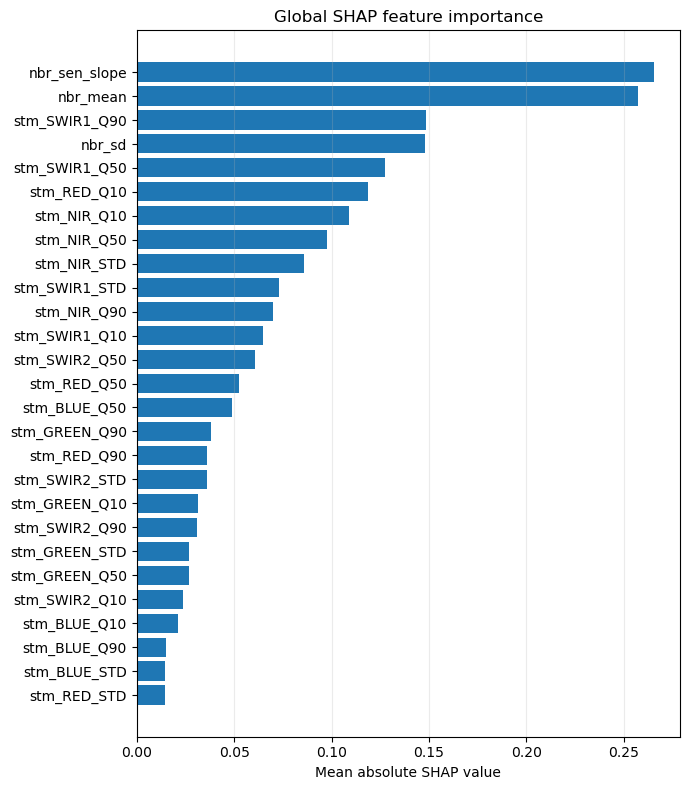

Saved: /mnt/eo/EO4Backcasting/_figures/shap/shap_global_feature_importance.png


In [8]:
# ============================================================
# 10. Plot global SHAP feature importance
# ============================================================

top_n = 27
imp_plot = importance_df.head(top_n).iloc[::-1]

fig, ax = plt.subplots(figsize=(7, 8))

ax.barh(
    imp_plot["feature"],
    imp_plot["mean_abs_shap"]
)

ax.set_xlabel("Mean absolute SHAP value")
ax.set_ylabel("")
ax.set_title("Global SHAP feature importance")
ax.grid(axis="x", alpha=0.25)

plt.tight_layout()

out_fp = out_dir / "shap_global_feature_importance.png"
fig.savefig(out_fp, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

print("Saved:", out_fp)

In [9]:
# ============================================================
# 11. SHAP dependence plot function
# ============================================================

def plot_shap_dependence(
    df_shap,
    feature,
    color_feature="prediction_probability",
    sample_n=150_000,
    out_dir=out_dir
):
    shap_col = f"shap_{feature}"

    needed_cols = [feature, shap_col]

    if color_feature is not None and color_feature in df_shap.columns:
        needed_cols.append(color_feature)

    plot_df = df_shap[needed_cols].copy()
    plot_df = plot_df.replace([np.inf, -np.inf], np.nan)
    plot_df = plot_df.dropna(subset=[feature, shap_col])

    if len(plot_df) > sample_n:
        plot_df = plot_df.sample(sample_n, random_state=42)

    fig, ax = plt.subplots(figsize=(6.4, 4.8))

    if color_feature is not None and color_feature in plot_df.columns:
        sc = ax.scatter(
            plot_df[feature],
            plot_df[shap_col],
            c=plot_df[color_feature],
            s=4,
            alpha=0.35,
            linewidths=0
        )

        cbar = plt.colorbar(sc, ax=ax)
        cbar.set_label(color_feature)

    else:
        ax.scatter(
            plot_df[feature],
            plot_df[shap_col],
            s=4,
            alpha=0.35,
            linewidths=0
        )

    ax.axhline(
        0,
        color="black",
        linewidth=0.8,
        linestyle="--",
        alpha=0.7
    )

    ax.set_xlabel(feature)
    ax.set_ylabel(f"SHAP value for {feature}")
    ax.set_title(f"SHAP dependence: {feature}")
    ax.grid(alpha=0.2)

    plt.tight_layout()

    suffix = f"_colored_by_{color_feature}" if color_feature else ""
    out_fp = out_dir / f"shap_dependence_{feature}{suffix}.png"

    fig.savefig(out_fp, dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()

    print("Saved:", out_fp)

In [10]:
# ============================================================
# 12. Select features for dependence plots
# ============================================================
# These are the most relevant ones for your backcasting story.

selected_features = [
    "nbr_sen_slope",
    "nbr_mean",
    "nbr_sd",
    "stm_NIR_Q50",
    "stm_SWIR1_Q50",
    "stm_SWIR2_Q50",
    "stm_NIR_STD",
    "stm_SWIR1_STD",
    "stm_SWIR2_STD",
]

# Keep only features that exist.
selected_features = [f for f in selected_features if f in feature_cols]

print(selected_features)

['nbr_sen_slope', 'nbr_mean', 'nbr_sd', 'stm_NIR_Q50', 'stm_SWIR1_Q50', 'stm_SWIR2_Q50', 'stm_NIR_STD', 'stm_SWIR1_STD', 'stm_SWIR2_STD']


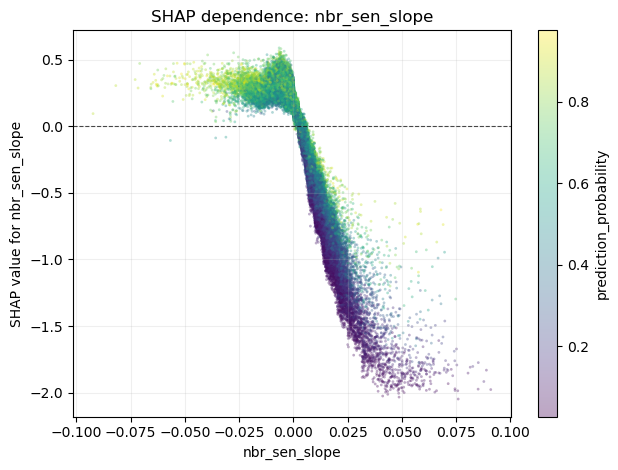

Saved: /mnt/eo/EO4Backcasting/_figures/shap/shap_dependence_nbr_sen_slope_colored_by_prediction_probability.png


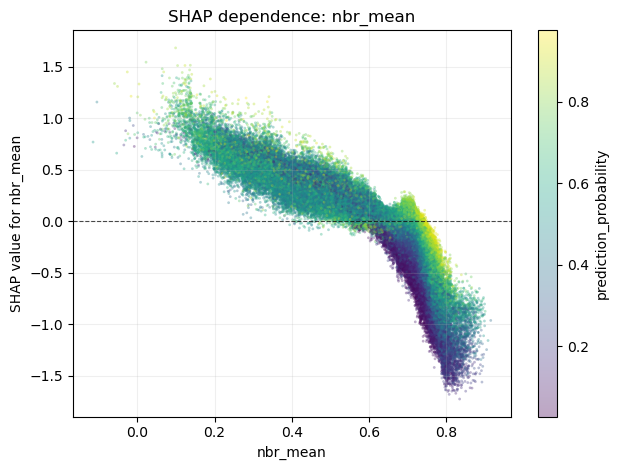

Saved: /mnt/eo/EO4Backcasting/_figures/shap/shap_dependence_nbr_mean_colored_by_prediction_probability.png


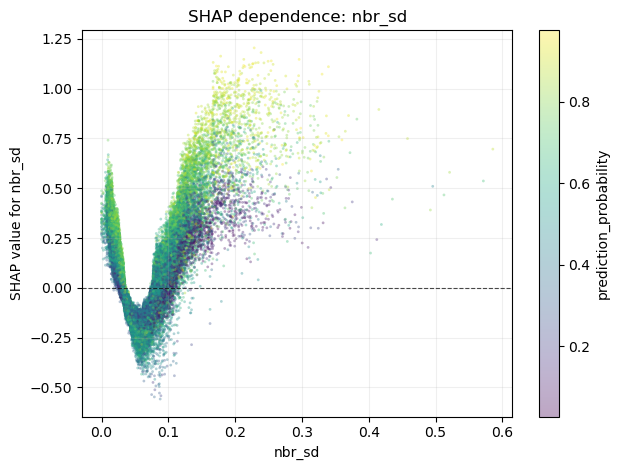

Saved: /mnt/eo/EO4Backcasting/_figures/shap/shap_dependence_nbr_sd_colored_by_prediction_probability.png


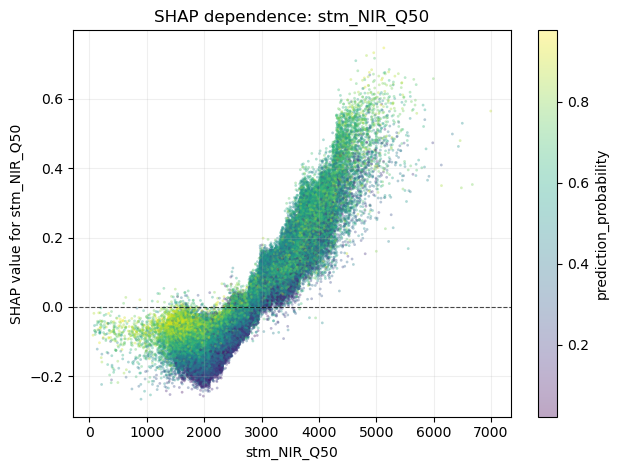

Saved: /mnt/eo/EO4Backcasting/_figures/shap/shap_dependence_stm_NIR_Q50_colored_by_prediction_probability.png


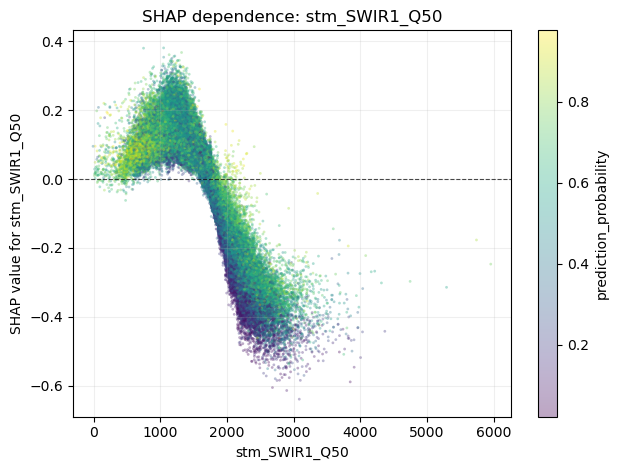

Saved: /mnt/eo/EO4Backcasting/_figures/shap/shap_dependence_stm_SWIR1_Q50_colored_by_prediction_probability.png


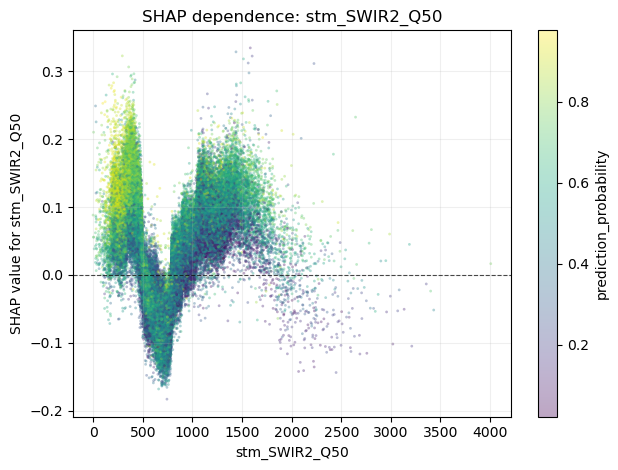

Saved: /mnt/eo/EO4Backcasting/_figures/shap/shap_dependence_stm_SWIR2_Q50_colored_by_prediction_probability.png


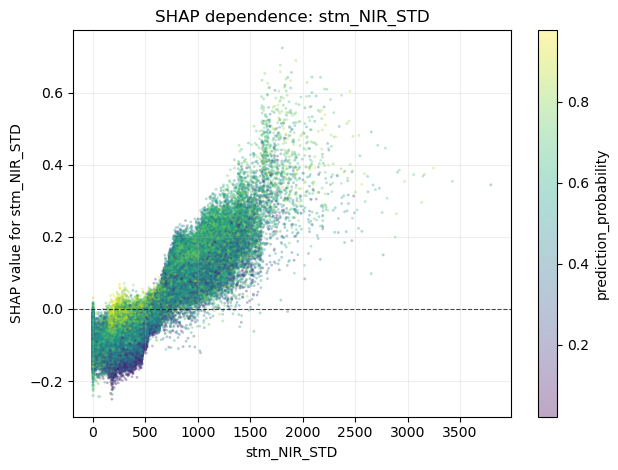

Saved: /mnt/eo/EO4Backcasting/_figures/shap/shap_dependence_stm_NIR_STD_colored_by_prediction_probability.png


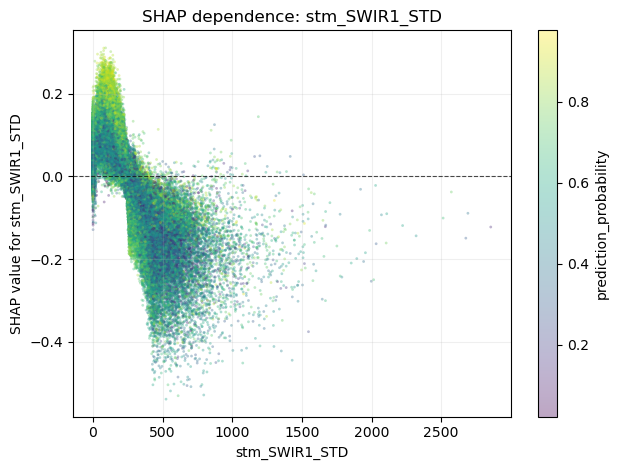

Saved: /mnt/eo/EO4Backcasting/_figures/shap/shap_dependence_stm_SWIR1_STD_colored_by_prediction_probability.png


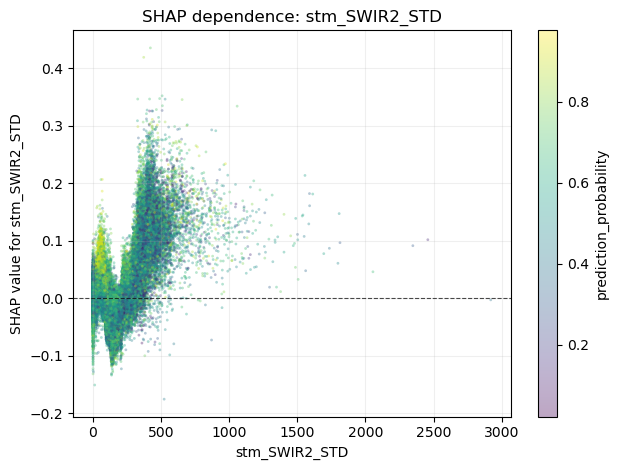

Saved: /mnt/eo/EO4Backcasting/_figures/shap/shap_dependence_stm_SWIR2_STD_colored_by_prediction_probability.png


In [11]:
# ============================================================
# 13. Make dependence plots
# ============================================================

for feat in selected_features:
    plot_shap_dependence(
        df_shap=df_shap,
        feature=feat,
        color_feature="prediction_probability",
        sample_n=150_000,
        out_dir=out_dir
    )

Top SHAP features:
['nbr_sen_slope', 'nbr_mean', 'stm_SWIR1_Q90', 'nbr_sd', 'stm_SWIR1_Q50', 'stm_RED_Q10', 'stm_NIR_Q10', 'stm_NIR_Q50']


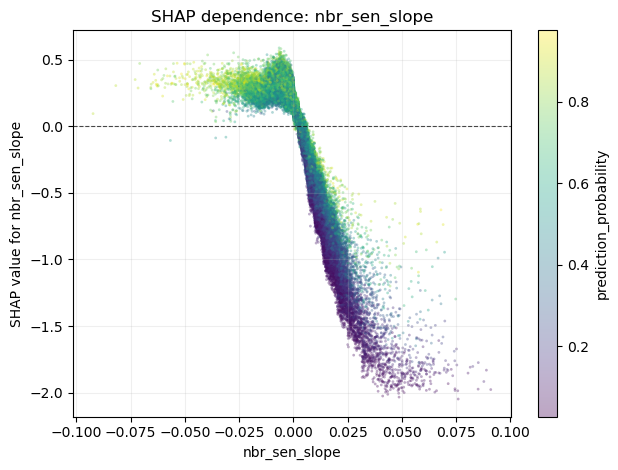

Saved: /mnt/eo/EO4Backcasting/_figures/shap/shap_dependence_nbr_sen_slope_colored_by_prediction_probability.png


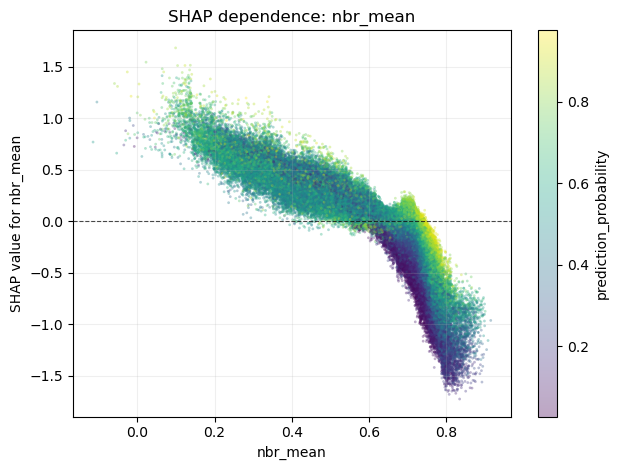

Saved: /mnt/eo/EO4Backcasting/_figures/shap/shap_dependence_nbr_mean_colored_by_prediction_probability.png


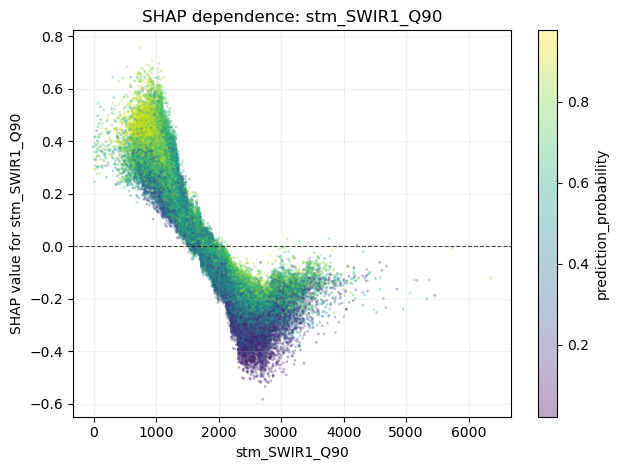

Saved: /mnt/eo/EO4Backcasting/_figures/shap/shap_dependence_stm_SWIR1_Q90_colored_by_prediction_probability.png


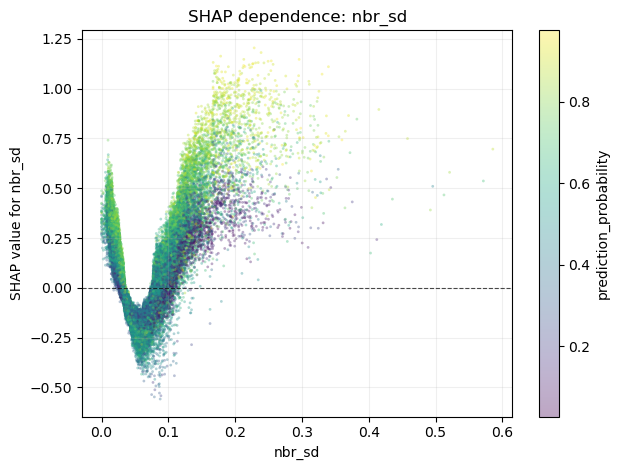

Saved: /mnt/eo/EO4Backcasting/_figures/shap/shap_dependence_nbr_sd_colored_by_prediction_probability.png


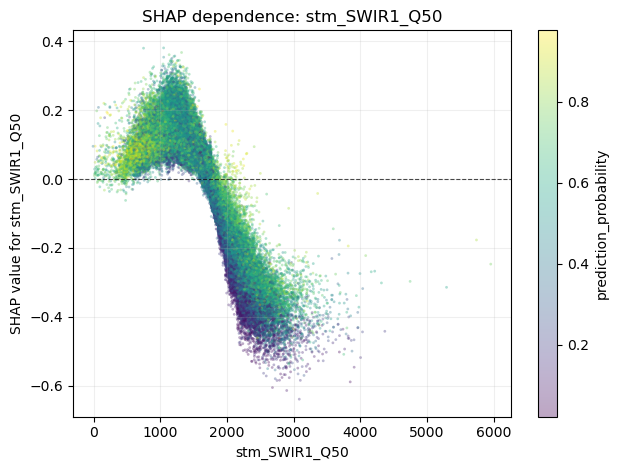

Saved: /mnt/eo/EO4Backcasting/_figures/shap/shap_dependence_stm_SWIR1_Q50_colored_by_prediction_probability.png


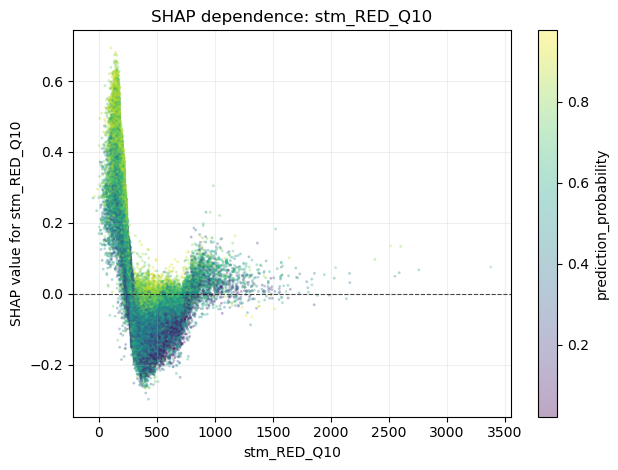

Saved: /mnt/eo/EO4Backcasting/_figures/shap/shap_dependence_stm_RED_Q10_colored_by_prediction_probability.png


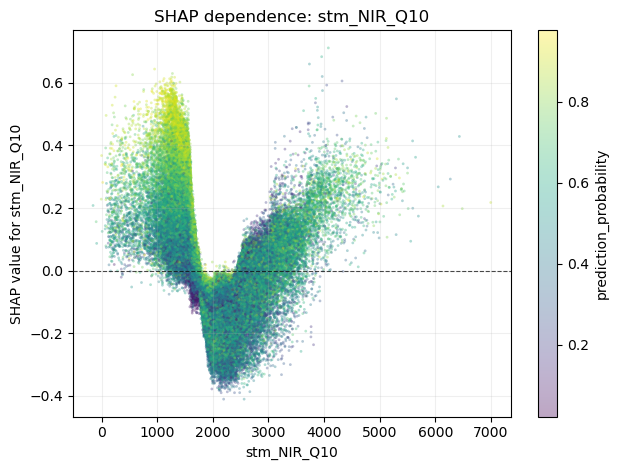

Saved: /mnt/eo/EO4Backcasting/_figures/shap/shap_dependence_stm_NIR_Q10_colored_by_prediction_probability.png


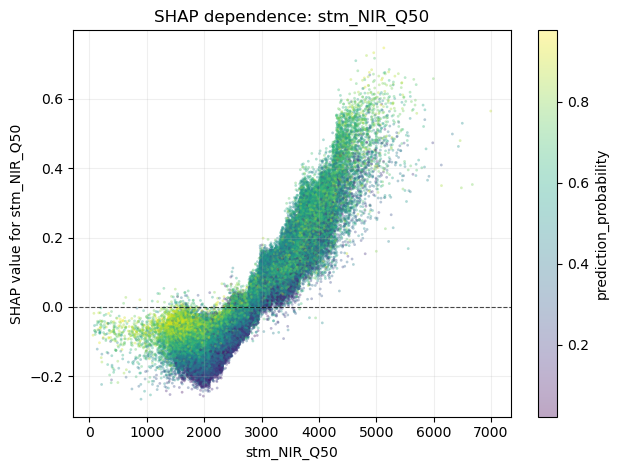

Saved: /mnt/eo/EO4Backcasting/_figures/shap/shap_dependence_stm_NIR_Q50_colored_by_prediction_probability.png


In [17]:
# ============================================================
# 14. Optional: dependence plots for top SHAP features
# ============================================================

top_features = importance_df["feature"].head(8).tolist()

print("Top SHAP features:")
print(top_features)

for feat in top_features:
    plot_shap_dependence(
        df_shap=df_shap,
        feature=feat,
        color_feature="prediction_probability",
        sample_n=150_000,
        out_dir=out_dir
    )

Top SHAP features:
['nbr_sen_slope', 'nbr_mean', 'stm_SWIR1_Q90', 'nbr_sd', 'stm_SWIR1_Q50', 'stm_RED_Q10', 'stm_NIR_Q10', 'stm_NIR_Q50']
Saved: /mnt/eo/EO4Backcasting/_figures/shap/shap_dependence_top8_custom_labels.png


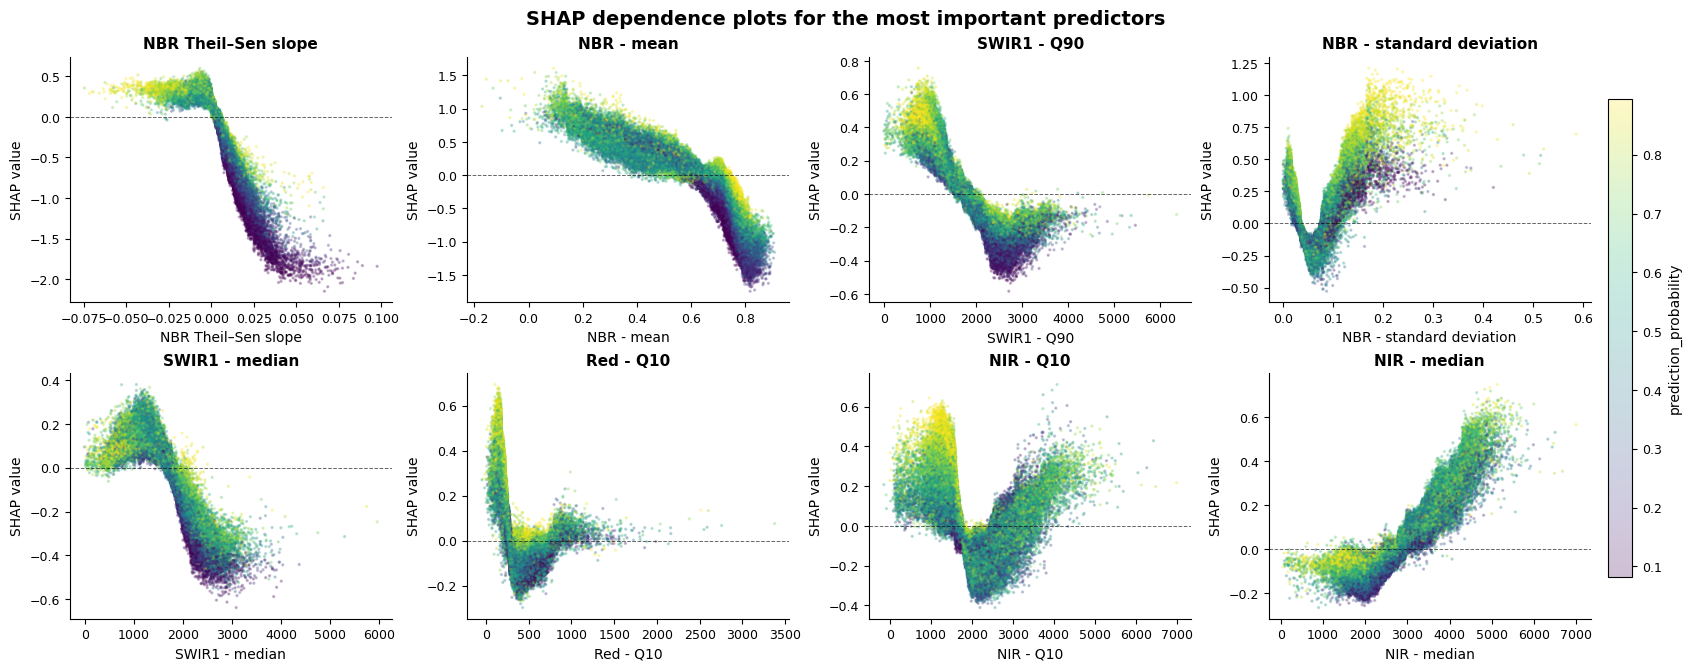

In [12]:
# ============================================================
# 14. SHAP dependence plots for top features with custom labels
#     Multi-panel figure
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------

out_dir = Path(out_dir)
out_dir.mkdir(parents=True, exist_ok=True)

top_features = importance_df["feature"].head(8).tolist()

print("Top SHAP features:")
print(top_features)

# ------------------------------------------------------------
# Custom labels
# Adapt this dictionary to your feature names
# ------------------------------------------------------------

feature_labels = {    
    "nbr_t0": "NBR at t₀",
    "nbr_mean": "NBR - mean",
    "nbr_min": "NBR - minimum",
    "nbr_max": "NBR - maximum",
    "nbr_sd": "NBR - standard deviation",
    "nbr_mad": "NBR - median absolute deviation",
    "nbr_range": "NBR - range",
    "nbr_sen_slope": "NBR Theil–Sen slope",
    
    "stm_BLUE_Q10": "Blue - Q10",
    "stm_BLUE_Q25": "Blue - Q25",
    "stm_BLUE_Q50": "Blue - median",
    "stm_BLUE_Q75": "Blue - Q75",
    "stm_BLUE_Q90": "Blue - Q90",
    "stm_BLUE_AVG": "Blue - mean",
    "stm_BLUE_STD": "Blue - standard deviation",

    "stm_GREEN_Q10": "Green - Q10",
    "stm_GREEN_Q25": "Green - Q25",
    "stm_GREEN_Q50": "Green - median",
    "stm_GREEN_Q75": "Green - Q75",
    "stm_GREEN_Q90": "Green - Q90",
    "stm_GREEN_AVG": "Green - mean",
    "stm_GREEN_STD": "Green - standard deviation",

    "stm_RED_Q10": "Red - Q10",
    "stm_RED_Q25": "Red - Q25",
    "stm_RED_Q50": "Red - median",
    "stm_RED_Q75": "Red - Q75",
    "stm_RED_Q90": "Red - Q90",
    "stm_RED_AVG": "Red - mean",
    "stm_RED_STD": "Red - standard deviation",

    "stm_NIR_Q10": "NIR - Q10",
    "stm_NIR_Q25": "NIR - Q25",
    "stm_NIR_Q50": "NIR - median",
    "stm_NIR_Q75": "NIR - Q75",
    "stm_NIR_Q90": "NIR - Q90",
    "stm_NIR_AVG": "NIR - mean",
    "stm_NIR_STD": "NIR - standard deviation",

    "stm_SWIR1_Q10": "SWIR1 - Q10",
    "stm_SWIR1_Q25": "SWIR1 - Q25",
    "stm_SWIR1_Q50": "SWIR1 - median",
    "stm_SWIR1_Q75": "SWIR1 - Q75",
    "stm_SWIR1_Q90": "SWIR1 - Q90",
    "stm_SWIR1_AVG": "SWIR1 - mean",
    "stm_SWIR1_STD": "SWIR1 - standard deviation",

    "stm_SWIR2_Q10": "SWIR2 - Q10",
    "stm_SWIR2_Q25": "SWIR2 - Q25",
    "stm_SWIR2_Q50": "SWIR2 - median",
    "stm_SWIR2_Q75": "SWIR2 - Q75",
    "stm_SWIR2_Q90": "SWIR2 - Q90",
    "stm_SWIR2_AVG": "SWIR2 - mean",
    "stm_SWIR2_STD": "SWIR2 - standard deviation",
}

# Falls ein Feature nicht im Dictionary steht, wird automatisch der Originalname verwendet
def nice_label(x):
    return feature_labels.get(x, x)


# ------------------------------------------------------------
# Plot function
# ------------------------------------------------------------

def plot_shap_dependence_grid(
    df_shap,
    features,
    color_feature="prediction_probability",
    sample_n=150_000,
    ncols=4,
    out_fp=None,
    point_size=2,
    alpha=0.25
):
    """
    Multi-panel SHAP dependence plot.
    
    Requires df_shap to contain:
    - each feature column, e.g. stm_NIR_Q50
    - corresponding SHAP columns named shap_<feature>, e.g. shap_stm_NIR_Q50
    - color_feature column, e.g. prediction_probability
    """

    # --------------------------------------------------------
    # Check required columns
    # --------------------------------------------------------

    missing = []

    for feat in features:
        shap_col = f"shap_{feat}"
        if feat not in df_shap.columns:
            missing.append(feat)
        if shap_col not in df_shap.columns:
            missing.append(shap_col)

    if color_feature not in df_shap.columns:
        missing.append(color_feature)

    if missing:
        raise ValueError(
            "Missing columns in df_shap:\n" + "\n".join(sorted(set(missing)))
        )

    # --------------------------------------------------------
    # Sample data
    # --------------------------------------------------------

    plot_cols = []
    for feat in features:
        plot_cols.extend([feat, f"shap_{feat}"])
    plot_cols.append(color_feature)

    df_plot = df_shap[plot_cols].replace([np.inf, -np.inf], np.nan).dropna()

    if sample_n is not None and len(df_plot) > sample_n:
        df_plot = df_plot.sample(sample_n, random_state=42)

    # --------------------------------------------------------
    # Figure layout
    # --------------------------------------------------------

    n_features = len(features)
    nrows = int(np.ceil(n_features / ncols))

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(4.2 * ncols, 3.3 * nrows),
        constrained_layout=True
    )

    axes = np.array(axes).reshape(-1)

    # Common color scale
    cmin = df_plot[color_feature].quantile(0.01)
    cmax = df_plot[color_feature].quantile(0.99)

    scatter_ref = None

    for i, feat in enumerate(features):
        ax = axes[i]
        shap_col = f"shap_{feat}"

        x = df_plot[feat]
        y = df_plot[shap_col]
        c = df_plot[color_feature]

        scatter_ref = ax.scatter(
            x,
            y,
            c=c,
            s=point_size,
            alpha=alpha,
            vmin=cmin,
            vmax=cmax,
            rasterized=True
        )

        ax.axhline(
            0,
            color="black",
            linewidth=0.7,
            linestyle="--",
            alpha=0.6
        )

        ax.set_title(
            nice_label(feat),
            fontsize=11,
            fontweight="bold"
        )

        ax.set_xlabel(nice_label(feat), fontsize=10)
        ax.set_ylabel("SHAP value", fontsize=10)

        ax.tick_params(axis="both", labelsize=9)

        for spine in ["top", "right"]:
            ax.spines[spine].set_visible(False)

    # Remove empty axes
    for j in range(n_features, len(axes)):
        axes[j].axis("off")

    # Shared colorbar
    cbar = fig.colorbar(
        scatter_ref,
        ax=axes[:n_features],
        shrink=0.85,
        pad=0.01
    )
    cbar.set_label(nice_label(color_feature), fontsize=10)
    cbar.ax.tick_params(labelsize=9)

    fig.suptitle(
        "SHAP dependence plots for the most important predictors",
        fontsize=14,
        fontweight="bold"
    )

    if out_fp is not None:
        fig.savefig(out_fp, dpi=300, bbox_inches="tight", facecolor="white")
        print("Saved:", out_fp)

    plt.show()

    return fig


# ------------------------------------------------------------
# Run plot
# ------------------------------------------------------------

out_fp = out_dir / "shap_dependence_top8_custom_labels.png"

fig = plot_shap_dependence_grid(
    df_shap=df_shap,
    features=top_features,
    color_feature="prediction_probability",
    sample_n=150_000,
    ncols=4,
    out_fp=out_fp,
    point_size=2,
    alpha=0.25
)

In [13]:
# ============================================================
# 15. Define SHAP feature groups
# ============================================================
# This grouping separates:
# - NBR dynamics after t0
# - within-year spectral variability
# - spectral level in visible / NIR / SWIR bands

def assign_feature_group(feature_name):
    f = feature_name.lower()

    if f.startswith("nbr_"):
        return "Post-1985 NBR dynamics"
    elif f.endswith("_std"):
        return "Within-year spectral variability"
    elif "swir1" in f or "swir2" in f:
        return "SWIR spectral level"
    elif "nir" in f:
        return "NIR spectral level"
    elif "blue" in f or "green" in f or "red" in f:
        return "Visible spectral level"
    else:
        return "Other"


feature_groups = pd.DataFrame({
    "feature": feature_cols,
    "group": [assign_feature_group(f) for f in feature_cols]
})

feature_groups

,feature,group
0,stm_BLUE_Q10,Visible spectral level
1,stm_BLUE_Q50,Visible spectral level
2,stm_BLUE_Q90,Visible spectral level
3,stm_BLUE_STD,Within-year spectral variability
4,stm_GREEN_Q10,Visible spectral level
5,stm_GREEN_Q50,Visible spectral level
6,stm_GREEN_Q90,Visible spectral level
7,stm_GREEN_STD,Within-year spectral variability
8,stm_RED_Q10,Visible spectral level
9,stm_RED_Q50,Visible spectral level


In [14]:
# ============================================================
# 16. Check feature grouping
# ============================================================

feature_groups.groupby("group")["feature"].apply(list)

group
NIR spectral level                            [stm_NIR_Q10, stm_NIR_Q50, stm_NIR_Q90]
Post-1985 NBR dynamics                              [nbr_mean, nbr_sd, nbr_sen_slope]
SWIR spectral level                 [stm_SWIR1_Q10, stm_SWIR1_Q50, stm_SWIR1_Q90, ...
Visible spectral level              [stm_BLUE_Q10, stm_BLUE_Q50, stm_BLUE_Q90, stm...
Within-year spectral variability    [stm_BLUE_STD, stm_GREEN_STD, stm_RED_STD, stm...
Name: feature, dtype: object

In [15]:
# ============================================================
# 17. Aggregate SHAP values by group
# ============================================================

group_names = feature_groups["group"].unique().tolist()

for group in group_names:
    group_features = feature_groups.loc[
        feature_groups["group"] == group,
        "feature"
    ].tolist()

    group_shap_cols = [f"shap_{f}" for f in group_features]

    df_shap[f"shap_group_{group}"] = df_shap[group_shap_cols].sum(axis=1)

group_shap_cols = [f"shap_group_{g}" for g in group_names]

print(group_shap_cols)

['shap_group_Visible spectral level', 'shap_group_Within-year spectral variability', 'shap_group_NIR spectral level', 'shap_group_SWIR spectral level', 'shap_group_Post-1985 NBR dynamics']


In [16]:
# ============================================================
# 18. Dominant positive SHAP group per point
# ============================================================
# This shows which feature group most strongly supports
# high forest-continuity probability at each location.

group_values = df_shap[group_shap_cols].to_numpy()

max_idx = np.argmax(group_values, axis=1)
max_val = np.max(group_values, axis=1)

dominant_group = np.array(group_names, dtype=object)[max_idx]
dominant_group[max_val <= 0] = "No positive contribution"

df_shap["dominant_positive_shap_group"] = dominant_group
df_shap["dominant_positive_shap_value"] = max_val

df_shap["dominant_positive_shap_group"].value_counts()

dominant_positive_shap_group
Post-1985 NBR dynamics              121250
SWIR spectral level                 113391
NIR spectral level                   52827
Visible spectral level               48546
Within-year spectral variability     38218
No positive contribution             16755
Name: count, dtype: int64

In [17]:
# ============================================================
# 19. Dominant negative SHAP group per point
# ============================================================
# This shows which feature group most strongly pushes predictions
# away from high forest-continuity probability.

min_idx = np.argmin(group_values, axis=1)
min_val = np.min(group_values, axis=1)

dominant_negative_group = np.array(group_names, dtype=object)[min_idx]
dominant_negative_group[min_val >= 0] = "No negative contribution"

df_shap["dominant_negative_shap_group"] = dominant_negative_group
df_shap["dominant_negative_shap_value"] = min_val

df_shap["dominant_negative_shap_group"].value_counts()

dominant_negative_shap_group
SWIR spectral level                 109393
Post-1985 NBR dynamics              106704
NIR spectral level                   72399
Visible spectral level               52319
Within-year spectral variability     29112
No negative contribution             21060
Name: count, dtype: int64

In [18]:
# ============================================================
# Save grouped SHAP table as CSV if it does not already exist
# ============================================================
# This table is lighter than df_shap_full.pkl because it keeps only IDs,
# prediction probability and grouped SHAP outputs.

keep_cols = [
    c for c in [
        "point_id",
        "t0",
        "x",
        "y",
        "tile",
        "biome",
        "label_undisturbed_20y",
        "prediction_probability",
        "dominant_positive_shap_group",
        "dominant_positive_shap_value",
        "dominant_negative_shap_group",
        "dominant_negative_shap_value",
    ]
    if c in df_shap.columns
]

keep_cols += group_shap_cols

if group_table_cache_fp.exists() and not overwrite_cache:
    print("Grouped SHAP table already exists, not overwriting:")
    print(group_table_cache_fp)
else:
    df_shap[keep_cols].to_csv(group_table_cache_fp, index=False)
    print("Saved grouped SHAP table:", group_table_cache_fp)


Saved grouped SHAP table: /mnt/eo/EO4Backcasting/_figures/shap/cache/shap_sample_with_group_contributions.csv


In [19]:
# ============================================================
# Load existing Europe-only spatial SHAP data or create it once
# ============================================================
# If shap_points_europe.gpkg and countries_europe_filtered.gpkg exist,
# they are loaded directly. Otherwise the Europe filter is applied and saved.

from shapely.geometry import box

if (
    gdf_shap_europe_cache_fp.exists()
    and countries_europe_cache_fp.exists()
    and not overwrite_cache
):
    print("Loading cached Europe-only SHAP points:")
    print(gdf_shap_europe_cache_fp)

    gdf_shap = gpd.read_file(gdf_shap_europe_cache_fp, layer="shap_points_europe")
    countries = gpd.read_file(countries_europe_cache_fp, layer="countries_europe")

    print("Loaded Europe-only SHAP rows:", len(gdf_shap))
    print("Loaded European country polygons:", len(countries))

else:
    print("No valid Europe-only spatial cache found. Creating spatial data now...")

    # --------------------------------------------------------
    # Convert SHAP table to GeoDataFrame
    # --------------------------------------------------------
    if "x" not in df_shap.columns or "y" not in df_shap.columns:
        raise ValueError("Spatial SHAP maps require x and y columns.")

    gdf_shap = gpd.GeoDataFrame(
        df_shap.copy(),
        geometry=gpd.points_from_xy(df_shap["x"], df_shap["y"]),
        crs="EPSG:3035"
    )

    print("SHAP rows before spatial filtering:", len(gdf_shap))
    print("SHAP CRS:", gdf_shap.crs)

    # --------------------------------------------------------
    # European country list and mainland bbox
    # --------------------------------------------------------
    european_countries = [
        "Albania", "Andorra", "Austria", "Belarus", "Belgium",
        "Bosnia and Herzegovina", "Bulgaria", "Croatia", "Czechia",
        "Denmark", "Estonia", "Finland", "France", "Germany",
        "Greece", "Hungary", "Ireland", "Italy", "Kosovo", "Latvia",
        "Liechtenstein", "Lithuania", "Luxembourg", "Moldova", "Monaco",
        "Montenegro", "Netherlands", "North Macedonia", "Norway", "Poland",
        "Portugal", "Romania", "San Marino", "Serbia", "Slovakia",
        "Slovenia", "Spain", "Sweden", "Switzerland", "Ukraine",
        "United Kingdom", "Vatican"
    ]

    # Mainland Europe extent in lon/lat.
    # Use xmax=45 if you want to keep the full eastern Ukraine.
    mainland_bbox_4326 = box(-11, 34, 45, 72)

    # --------------------------------------------------------
    # Load country polygons
    # --------------------------------------------------------
    if countries_fp is None or not Path(countries_fp).exists():
        raise FileNotFoundError(
            "countries_fp is missing. Set countries_fp to a valid European country boundary file."
        )

    countries_raw = gpd.read_file(countries_fp)

    print("Country columns:")
    print(countries_raw.columns.tolist())

    possible_name_cols = [
        "NAME_ENGL",  # common in Eurostat CNTR files
        "NAME", "NAME_EN", "ADMIN", "SOVEREIGNT", "name", "name_en",
        "country", "CNTR_NAME", "NAME_LONG"
    ]

    name_col = None
    for col in possible_name_cols:
        if col in countries_raw.columns:
            name_col = col
            break

    if name_col is None:
        raise ValueError(
            "Could not detect country-name column. "
            "Inspect countries_raw.columns and set name_col manually."
        )

    print("Using country-name column:", name_col)

    # --------------------------------------------------------
    # Filter in EPSG:4326 and remove overseas territories
    # --------------------------------------------------------
    countries_4326 = countries_raw.to_crs("EPSG:4326")

    countries_4326 = countries_4326[
        countries_4326[name_col].isin(european_countries)
    ].copy()

    print("Countries after name filter:", countries_4326[name_col].nunique())
    print(sorted(countries_4326[name_col].unique()))

    # Clip to mainland Europe bbox. This removes overseas parts inside multipolygons.
    countries_4326["geometry"] = countries_4326.geometry.intersection(mainland_bbox_4326)
    countries_4326 = countries_4326[~countries_4326.geometry.is_empty].copy()

    # Explode multipolygons and remove tiny fragments/slivers
    countries_4326 = countries_4326.explode(index_parts=False).reset_index(drop=True)

    countries = countries_4326.to_crs("EPSG:3035")
    countries["area_km2"] = countries.geometry.area / 1e6

    min_area_km2 = 50
    countries = countries[countries["area_km2"] >= min_area_km2].copy()

    print("European country polygons after bbox/sliver filter:", len(countries))

    # --------------------------------------------------------
    # Spatially filter SHAP points to European countries
    # --------------------------------------------------------
    if gdf_shap.crs != countries.crs:
        gdf_shap = gdf_shap.to_crs(countries.crs)

    gdf_shap = gpd.sjoin(
        gdf_shap,
        countries[["geometry"]],
        how="inner",
        predicate="within"
    ).drop(columns=["index_right"])

    print("SHAP rows after European spatial filter:", len(gdf_shap))

    # Keep df_shap consistent if used later
    df_shap = pd.DataFrame(gdf_shap.drop(columns="geometry")).copy()

    # --------------------------------------------------------
    # Save spatial cache
    # --------------------------------------------------------
    gdf_shap.to_file(
        gdf_shap_europe_cache_fp,
        layer="shap_points_europe",
        driver="GPKG"
    )

    countries.to_file(
        countries_europe_cache_fp,
        layer="countries_europe",
        driver="GPKG"
    )

    print("Saved Europe-only SHAP points:", gdf_shap_europe_cache_fp)
    print("Saved filtered European countries:", countries_europe_cache_fp)

print("Final Europe-only SHAP rows:", len(gdf_shap))
print("Final country polygons:", len(countries))


No valid Europe-only spatial cache found. Creating spatial data now...
SHAP rows before spatial filtering: 390987
SHAP CRS: EPSG:3035
Country columns:
['CNTR_ID', 'COUNTRY_URI', 'CNTR_NAME', 'NAME_ENGL', 'NAME_FREN', 'ISO3_CODE', 'SVRG_UN', 'CAPT', 'STAT_CODE', 'EU_STAT', 'EFTA_STAT', 'CC_STAT', 'NAME_GERM', 'geometry']
Using country-name column: NAME_ENGL
Countries after name filter: 40
['Albania', 'Andorra', 'Austria', 'Belarus', 'Belgium', 'Bosnia and Herzegovina', 'Bulgaria', 'Croatia', 'Czechia', 'Denmark', 'Estonia', 'Finland', 'France', 'Germany', 'Greece', 'Hungary', 'Ireland', 'Italy', 'Latvia', 'Liechtenstein', 'Lithuania', 'Luxembourg', 'Moldova', 'Monaco', 'Montenegro', 'Netherlands', 'North Macedonia', 'Norway', 'Poland', 'Portugal', 'Romania', 'San Marino', 'Serbia', 'Slovakia', 'Slovenia', 'Spain', 'Sweden', 'Switzerland', 'Ukraine', 'United Kingdom']
European country polygons after bbox/sliver filter: 176
SHAP rows after European spatial filter: 379431
Saved Europe-only

In [39]:
# ============================================================
# Rename SHAP group labels for cleaner legend
# ============================================================

group_rename = {
    "SWIR spectral level": "SWIR reflectance",
    "NIR spectral level": "NIR reflectance",
    "Visible spectral level": "Visible reflectance",
}

for col in [
    "dominant_positive_shap_group",
    "dominant_negative_shap_group",
]:
    if col in gdf_shap.columns:
        gdf_shap[col] = gdf_shap[col].replace(group_rename)

if "dominant_positive_shap_group" in df_shap.columns:
    df_shap["dominant_positive_shap_group"] = df_shap[
        "dominant_positive_shap_group"
    ].replace(group_rename)

if "dominant_negative_shap_group" in df_shap.columns:
    df_shap["dominant_negative_shap_group"] = df_shap[
        "dominant_negative_shap_group"
    ].replace(group_rename)

High-probability rows: 20005
dominant_positive_shap_group
SWIR reflectance                    9903
Recovery proxy (NBR trend)          6294
Visible reflectance                 2723
NIR reflectance                      898
Within-year spectral variability     187
Name: count, dtype: int64


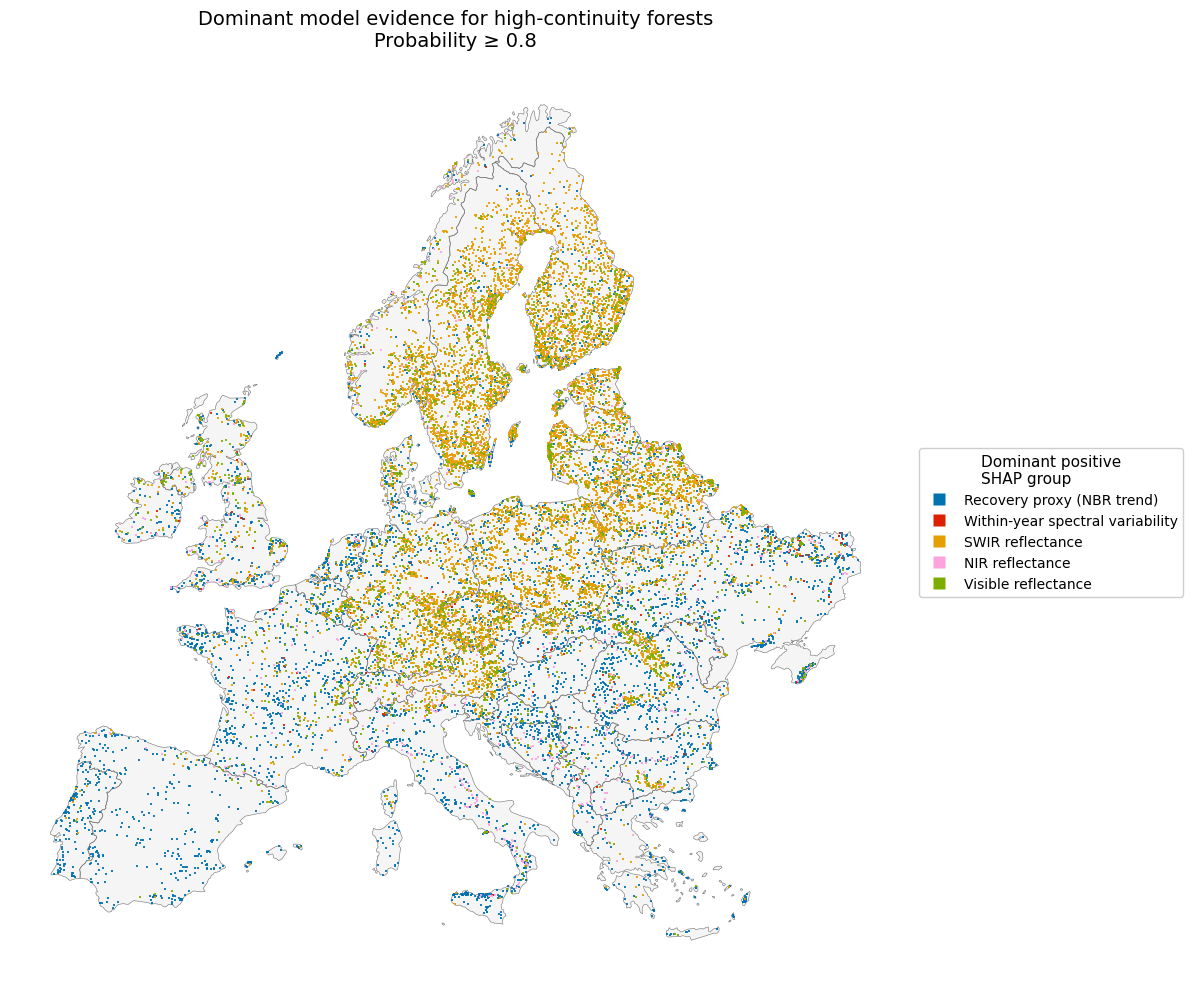

Saved: /mnt/eo/EO4Backcasting/_figures/shap/spatial_dominant_positive_shap_group_prob_ge_80_final_labels_right_legend.png


In [52]:
# ============================================================
# Spatial map only for high-probability forests
# better visible version + final renamed labels + legend on right
# ============================================================

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------

prob_threshold = 0.80
show_no_positive = False

marker_size = 4
marker_alpha = 0.90

# ------------------------------------------------------------
# Rename SHAP group labels for cleaner legend
# ------------------------------------------------------------

group_rename = {
    "Post-1985 NBR dynamics": "Recovery proxy (NBR trend)",
    "SWIR spectral level": "SWIR reflectance",
    "NIR spectral level": "NIR reflectance",
    "Visible spectral level": "Visible reflectance",
}

for col in ["dominant_positive_shap_group", "dominant_negative_shap_group"]:
    if col in gdf_shap.columns:
        gdf_shap[col] = gdf_shap[col].replace(group_rename)

# ------------------------------------------------------------
# Subset high-probability forests
# ------------------------------------------------------------

gdf_high = gdf_shap[
    gdf_shap["prediction_probability"] >= prob_threshold
].copy()

if not show_no_positive:
    gdf_high = gdf_high[
        gdf_high["dominant_positive_shap_group"] != "No positive contribution"
    ].copy()

print("High-probability rows:", len(gdf_high))
print(gdf_high["dominant_positive_shap_group"].value_counts())

# ------------------------------------------------------------
# Contrasting colors
# ------------------------------------------------------------

group_colors = {
    "Recovery proxy (NBR trend)": "#0072B2",
    "Within-year spectral variability": "#DB2100",
    "SWIR reflectance": "#E69F00",
    "NIR reflectance": "#FFA3DF",
    "Visible reflectance": "#7CAE00",
    "Other": "#4D4D4D",
    "No positive contribution": "#D9D9D9",
}

group_order = [
    "Recovery proxy (NBR trend)",
    "Within-year spectral variability",
    "SWIR reflectance",
    "NIR reflectance",
    "Visible reflectance",
    "Other",
    "No positive contribution",
]

group_order = [
    g for g in group_order
    if g in gdf_high["dominant_positive_shap_group"].unique()
]

# Safety check
missing_colors = [
    g for g in gdf_high["dominant_positive_shap_group"].unique()
    if g not in group_colors
]

if missing_colors:
    raise ValueError(
        "Missing colors for these SHAP groups: "
        f"{missing_colors}. Add them to group_colors."
    )

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 10.5))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

if countries is not None:
    countries.plot(
        ax=ax,
        facecolor="#f5f5f5",
        edgecolor="none",
        zorder=0
    )

    countries.boundary.plot(
        ax=ax,
        color="#6f6f6f",
        linewidth=0.45,
        alpha=0.9,
        zorder=1
    )

for group in group_order:
    sub = gdf_high[
        gdf_high["dominant_positive_shap_group"] == group
    ]

    if len(sub) == 0:
        continue

    sub.plot(
        ax=ax,
        color=group_colors[group],
        markersize=marker_size,
        alpha=marker_alpha,
        linewidth=0,
        marker="s",
        zorder=2
    )

# ------------------------------------------------------------
# Legend on the right
# ------------------------------------------------------------

legend_handles = [
    Line2D(
        [0],
        [0],
        marker="s",
        color="none",
        markerfacecolor=group_colors[g],
        markeredgecolor="none",
        markersize=8,
        label=g
    )
    for g in group_order
]

ax.legend(
    handles=legend_handles,
    title="Dominant positive\nSHAP group",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=True,
    facecolor="white",
    framealpha=0.95,
    fontsize=10,
    title_fontsize=11,
    borderaxespad=0.0
)

# ------------------------------------------------------------
# Title and layout
# ------------------------------------------------------------

ax.set_title(
    f"Dominant model evidence for high-continuity forests\nProbability ≥ {prob_threshold}",
    fontsize=14,
    pad=12
)

ax.set_axis_off()
ax.set_aspect("equal")

plt.subplots_adjust(right=0.78)
plt.tight_layout()

out_fp = out_dir / (
    f"spatial_dominant_positive_shap_group_"
    f"prob_ge_{int(prob_threshold * 100)}_final_labels_right_legend.png"
)

fig.savefig(
    out_fp,
    dpi=400,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print("Saved:", out_fp)

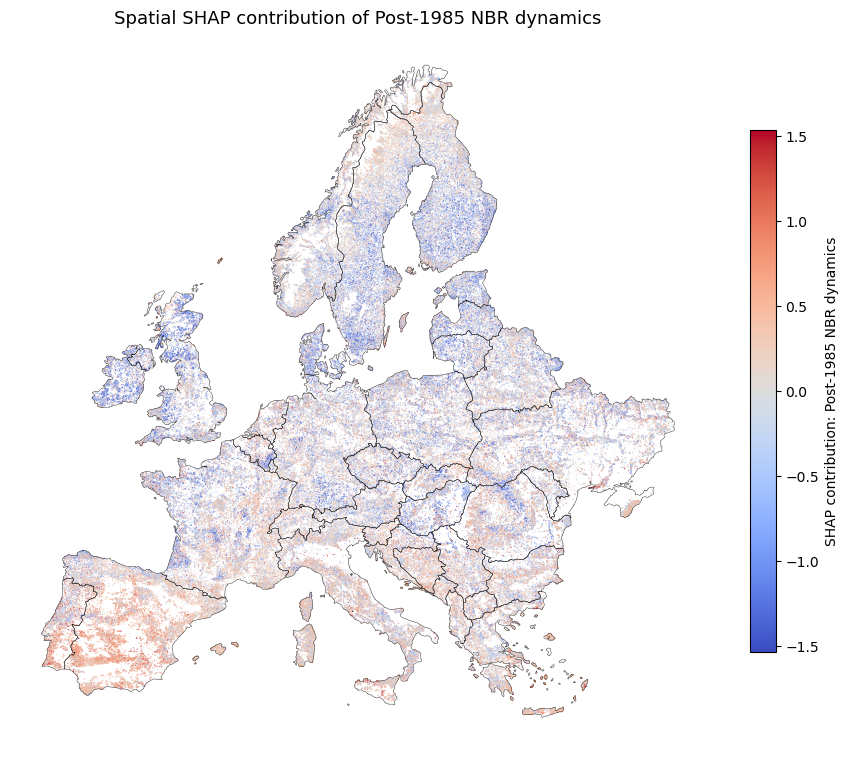

Saved: /mnt/eo/EO4Backcasting/_figures/shap/spatial_shap_contribution_Post_1985_NBR_dynamics.png


In [23]:
# ============================================================
# 25. Spatial map of one SHAP group contribution
# ============================================================
# Change this to any group in group_names.

target_group = "Post-1985 NBR dynamics"
target_col = f"shap_group_{target_group}"

plot_gdf = gdf_shap.copy()
plot_gdf = plot_gdf.replace([np.inf, -np.inf], np.nan)
plot_gdf = plot_gdf.dropna(subset=[target_col])

vmax = np.nanpercentile(np.abs(plot_gdf[target_col]), 98)
vmin = -vmax

fig, ax = plt.subplots(figsize=(9, 9))

if countries is not None:
    countries.boundary.plot(
        ax=ax,
        color="black",
        linewidth=0.35,
        alpha=0.8,
        zorder=2
    )

plot_gdf.plot(
    ax=ax,
    column=target_col,
    cmap="coolwarm",
    vmin=vmin,
    vmax=vmax,
    markersize=0.5,
    alpha=0.7,
    linewidth=0,
    legend=True,
    legend_kwds={
        "label": f"SHAP contribution: {target_group}",
        "shrink": 0.6
    },
    zorder=1
)

ax.set_title(
    f"Spatial SHAP contribution of {target_group}",
    fontsize=13
)

ax.set_axis_off()
ax.set_aspect("equal")

plt.tight_layout()

out_fp = out_dir / f"spatial_shap_contribution_{target_group.replace(' ', '_').replace('-', '_')}.png"
fig.savefig(out_fp, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

print("Saved:", out_fp)

Rows before filtering: 379431
Rows for facet maps: 20005
Resolved SHAP group columns:
Recovery proxy (NBR trend) -> shap_group_Post-1985 NBR dynamics
Within-year spectral variability -> shap_group_Within-year spectral variability
SWIR reflectance -> shap_group_SWIR spectral level
NIR reflectance -> shap_group_NIR spectral level
Visible reflectance -> shap_group_Visible spectral level
Shared color scale:
vmin: 0
vmax: 1.2314204311370858
Recovery proxy (NBR trend) positive rows: 17447
Within-year spectral variability positive rows: 17095
SWIR reflectance positive rows: 16710
NIR reflectance positive rows: 18088
Visible reflectance positive rows: 19292


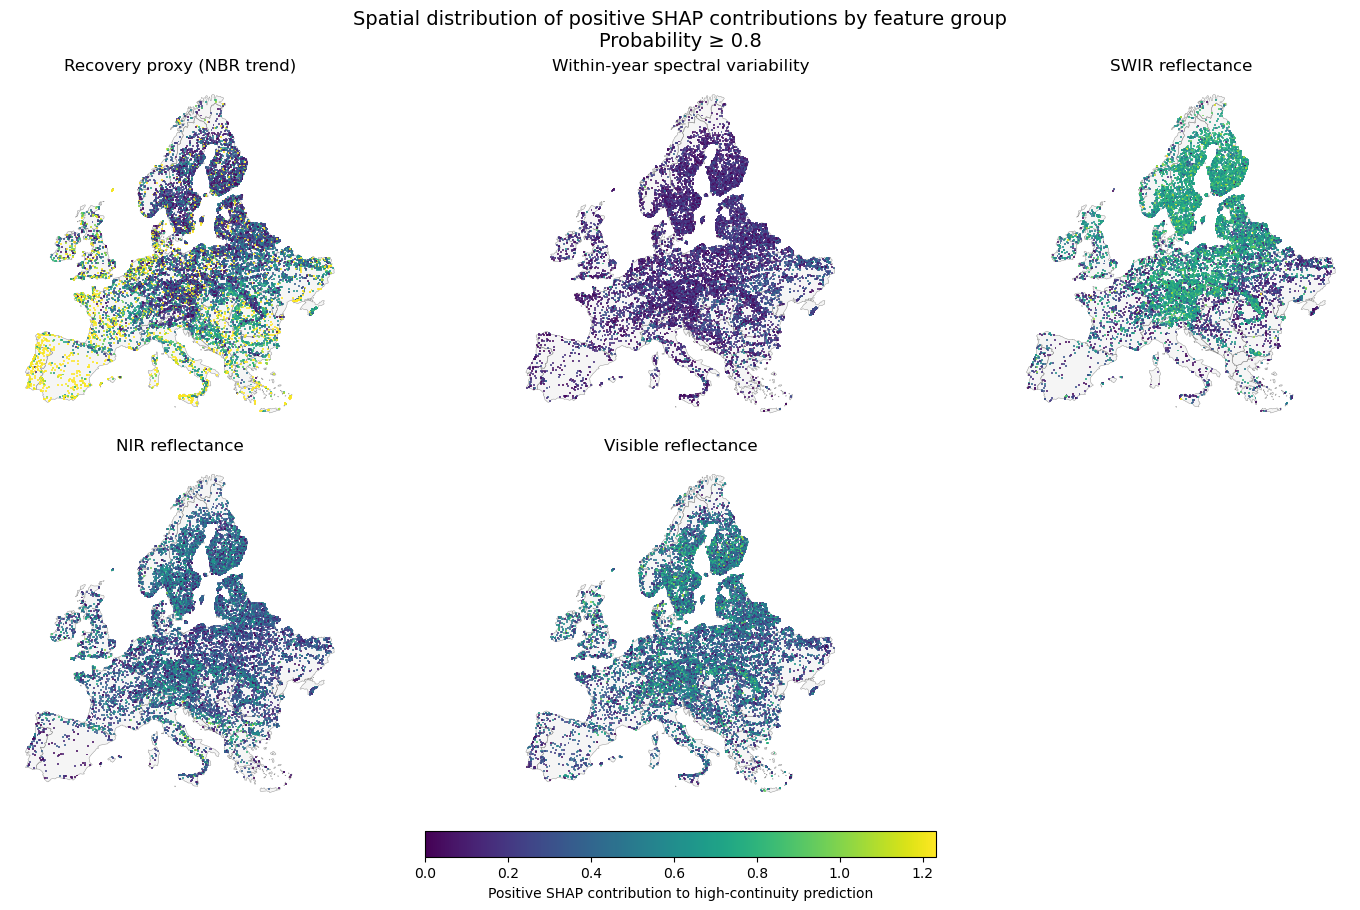

Saved: /mnt/eo/EO4Backcasting/_figures/shap/facet_maps_positive_shap_groups_prob_ge_80_final_labels.png


In [49]:
# ============================================================
# Facet maps: positive SHAP contribution per feature group
# with final renamed labels
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------

prob_threshold = 0.80
marker_size = 2
marker_alpha = 0.80

# ------------------------------------------------------------
# Subset high-probability forests
# ------------------------------------------------------------

gdf_plot = gdf_shap[
    gdf_shap["prediction_probability"] >= prob_threshold
].copy()

print("Rows before filtering:", len(gdf_shap))
print("Rows for facet maps:", len(gdf_plot))

# ------------------------------------------------------------
# Rename dominant SHAP group labels
# ------------------------------------------------------------

group_rename = {
    "Post-1985 NBR dynamics": "Recovery proxy (NBR trend)",
    "SWIR spectral level": "SWIR reflectance",
    "NIR spectral level": "NIR reflectance",
    "Visible spectral level": "Visible reflectance",
}

for col in ["dominant_positive_shap_group", "dominant_negative_shap_group"]:
    if col in gdf_plot.columns:
        gdf_plot[col] = gdf_plot[col].replace(group_rename)

# ------------------------------------------------------------
# Define SHAP group columns with final display labels
# ------------------------------------------------------------

plot_groups = {
    "Recovery proxy (NBR trend)": [
        "shap_group_Recovery proxy (NBR trend)",
        "shap_group_Post-1985 NBR dynamics",
    ],
    "Within-year spectral variability": [
        "shap_group_Within-year spectral variability"
    ],
    "SWIR reflectance": [
        "shap_group_SWIR reflectance",
        "shap_group_SWIR spectral level"
    ],
    "NIR reflectance": [
        "shap_group_NIR reflectance",
        "shap_group_NIR spectral level"
    ],
    "Visible reflectance": [
        "shap_group_Visible reflectance",
        "shap_group_Visible spectral level"
    ],
}

# Resolve to the actually existing column names
plot_groups_resolved = {}

for label, candidate_cols in plot_groups.items():
    found_col = None

    for col in candidate_cols:
        if col in gdf_plot.columns:
            found_col = col
            break

    if found_col is not None:
        plot_groups_resolved[label] = found_col

print("Resolved SHAP group columns:")
for label, col in plot_groups_resolved.items():
    print(f"{label} -> {col}")

if len(plot_groups_resolved) == 0:
    raise ValueError("No SHAP group columns found. Check column names in gdf_shap.")

# ------------------------------------------------------------
# Convert to positive-only SHAP contribution
# ------------------------------------------------------------

for label, col in plot_groups_resolved.items():
    pos_col = col + "_positive"
    gdf_plot[pos_col] = gdf_plot[col].clip(lower=0)

# ------------------------------------------------------------
# Shared color scale across all panels
# ------------------------------------------------------------

positive_cols = [
    col + "_positive"
    for col in plot_groups_resolved.values()
]

all_positive_values = np.concatenate([
    gdf_plot[c].dropna().to_numpy()
    for c in positive_cols
    if gdf_plot[c].notna().any()
])

vmin = 0
vmax = np.nanpercentile(all_positive_values, 98)

print("Shared color scale:")
print("vmin:", vmin)
print("vmax:", vmax)

norm = Normalize(vmin=vmin, vmax=vmax)
cmap = plt.cm.viridis
sm = ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

# ------------------------------------------------------------
# Plot facet maps
# ------------------------------------------------------------

n_groups = len(plot_groups_resolved)
ncols = 3
nrows = int(np.ceil(n_groups / ncols))

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(15, 9),
    constrained_layout=True
)

axes = np.array(axes).reshape(-1)

for ax, (label, col) in zip(axes, plot_groups_resolved.items()):

    pos_col = col + "_positive"

    ax.set_facecolor("white")

    if countries is not None:
        countries.plot(
            ax=ax,
            facecolor="#f5f5f5",
            edgecolor="none",
            zorder=0
        )

        countries.boundary.plot(
            ax=ax,
            color="#8a8a8a",
            linewidth=0.35,
            alpha=0.9,
            zorder=1
        )

    sub = gdf_plot[
        gdf_plot[pos_col] > 0
    ].copy()

    print(label, "positive rows:", len(sub))

    if len(sub) > 0:
        sub.plot(
            ax=ax,
            column=pos_col,
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            markersize=marker_size,
            alpha=marker_alpha,
            linewidth=0,
            marker="s",
            zorder=2
        )

    ax.set_title(label, fontsize=12)
    ax.set_axis_off()
    ax.set_aspect("equal")

# Remove unused axes
for ax in axes[n_groups:]:
    ax.set_visible(False)

# ------------------------------------------------------------
# Shared colorbar
# ------------------------------------------------------------

cbar = fig.colorbar(
    sm,
    ax=axes[:n_groups],
    orientation="horizontal",
    fraction=0.035,
    pad=0.03
)

cbar.set_label(
    "Positive SHAP contribution to high-continuity prediction",
    fontsize=10
)

fig.suptitle(
    f"Spatial distribution of positive SHAP contributions by feature group\n"
    f"Probability ≥ {prob_threshold}",
    fontsize=14
)

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

out_fp = out_dir / (
    f"facet_maps_positive_shap_groups_"
    f"prob_ge_{int(prob_threshold * 100)}_final_labels.png"
)

fig.savefig(
    out_fp,
    dpi=400,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print("Saved:", out_fp)

In [ ]:
# ============================================================
# Optional: copy/save Europe-only SHAP GeoPackage for QGIS
# ============================================================
# The Europe-only GeoPackage is already written to:
#   gdf_shap_europe_cache_fp
# This block writes an additional copy in out_dir only if needed.

out_gpkg = out_dir / "shap_sample_spatial_europe_only.gpkg"

if out_gpkg.exists() and not overwrite_cache:
    print("QGIS GeoPackage already exists, not overwriting:")
    print(out_gpkg)
else:
    gdf_shap.to_file(
        out_gpkg,
        layer="shap_points_europe",
        driver="GPKG"
    )
    print("Saved QGIS GeoPackage:", out_gpkg)
